Previously, we looked at how exploiting the symmetries of a simple game of Connect 4 on a reduced grid can help us reduce the number of trainable parameters in a system. The symmetry of that system was Z2, and ultimately did not prove large enough to get results that were particularly better than ignoring the symmetries themselves.

So let's look at a better system! The system I am proposing is as follows. For a group of nodes, with a random number of lines connecting each of the nodes. If a triangle is formed between any of these nodes, the output is yes. If not, then no. This is a deceptively simple problem which actually has a certain amount of richness that makes it a perfect candidate for our circuit. I'll be referring to these lines as 'edges', just FYI. 

To better illustrate the idea here, I will begin with the code for a system with 5 nodes.

In [1]:
import numpy as np
from itertools import combinations

np.random.seed(3)

NODES = 5
EDGE_PROB = 0.5

# Find all possible edges between the nodes (lines that can be drawn between the nodes)
edges = list(combinations(range(NODES), 2))

Let's see what the possible combinations are. There should be 10 different lines that can be drawn between the points. The qubits this time will be assigned to each of these lines.

In [2]:
print(edges)
QUBITS = len(edges)

[(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]


Similarly to before, quickly write a mapping between the edge and the qubit this assigns to. 

In [3]:
edge_to_qubit = {e: k for k, e in enumerate(edges)}
print(edge_to_qubit)

{(0, 1): 0, (0, 2): 1, (0, 3): 2, (0, 4): 3, (1, 2): 4, (1, 3): 5, (1, 4): 6, (2, 3): 7, (2, 4): 8, (3, 4): 9}


So the line between node 0 and 1 maps to the qubit with index 0, 0 -> 2 maps to qubit 1 etc etc. Now to create random graphs, and define how we find the triangles.

In [4]:
def random_graph():
    """
    Randomly include each edge with probability EDGE_PROB

    Returns a dict {edge: 0 or 1} which maps to whether an edge is present
    """
    # Create a random array of numbers between 0 and 1, then convert to int to get 0s and 1s
    present = (np.random.random(QUBITS) < EDGE_PROB).astype(int)
    return dict(zip(edges, present))

def find_triangles(graph):
    # Create a set so no duplicates
    triangles = set()
    # Extract the points, and see if each of the 3 points is present in the graph
    for a, b, c in combinations(range(NODES), 3):
        if graph[(a, b)] and graph[(a, c)] and graph[(b, c)]:
            triangles.add((a, b, c))
    return triangles

Now to run a quick sim:

In [5]:
def play_game():
    graph = random_graph()
    present_edges = sorted(e for e, on in graph.items() if on)
    triangles = find_triangles(graph)

    print(f"Nodes: {NODES}")
    print(f"Edges: {present_edges}")
    print(f"Triangles: {triangles}")

play_game()

Nodes: 5
Edges: [(0, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
Triangles: {(2, 3, 4)}


So, a line was drawn between points 2 and 3, 3 and 4, and 2 and 4, making a triangle.

So where do the symmetries come from this time? It's actually more subtle - don't be fooled by my nice pentagon drawing as my way of representing the nodes. The system I devised knows nothing about 'shape' - the nodes could all be bunched together or in a line, all that matters is the connections between the points. The symmetry at large here is much more powerful than any sort of geometric one. You may have already noticed it while working through; the nodes can be labelled in any way. Look at the image I draw again, why did I choose node 0 there and node 1 there. What changes about the problem if I were to swap these labels, like this?

The answer is absolutely nothing of course! This is a S5 symmetry. Let's get the group theory stuff out of the way quickly. These indices can be relabelled 5! = 120 different ways, so this group has 120 elements. The nodes are what the group permutes, but the qubits sit on the edges here, which in fact are impacted by the relabelling! 

Let's say an edge exists between qubits 0 and 1. Now, relabel the qubits themselves and swap them, so qubit 0 is now qubit 1 and vice-versa. Naturally, the graph still remains the same, any triangles that were there before will be there now, but the wire for edge (0, 2) now describes edge (1, 2)... which maps to qubit 4!
In the same way, the wire for edge (1, 2) now describes edge (0, 2)... which is qubit 1! So qubits 1 and 4 traded their 'contents' (and same for the other permutations included). 

This isn't an issue or anything, but it tells us that relabelling the nodes simply swaps the wires around. No values were flipped or rotated, the bits just slid into different slots. Every one of the 120 relabelling is like this, just shuffling our qubits around and nothing else. In the circuit sense, this means we never have to worry about the wires fighting with the gates, a gate can just be commuted past a wire-swap by swapping the wires it acts on. 

Now to find the number of orbits. Remember an orbit is, when applying the symmetry, collect everything the symmetry can turn into. Two objects are in the same orbit when some node-relabelling turns one into the other, so the group simply cannot tell them apart. 

So, all that needs to be done is to go through each of the 120 relabellings and find all these invariances, easy. Actually that would suck, so let's just find the pattern behind it all. 

First, have a look at the single edges (single rotation gates). What is true about an edge which survives every relabelling? Well, nothing actually. Every edge is just a line between nodes, and relabelling erases which two nodes they were, so these make up just one orbit.

How about pairs of edges (the entangling gates). Under relabelling, what's the same? Many things! Namely, the relabelling cannot change how many nodes the two edges share. Renaming nodes never changes whether two lines meet at a point. Two distinct edges can only share 1 node, or share 0 nodes (is there a line or not!?). This makes 2 more orbits.

How about triangles (the measurement/output)? Any node-triplet can be relabelled into any other, so all 5C3 = 10 triangle slots are 1 orbit. 

So wait, how many orbits do we have? Well each number here is counting a different kind of object: single qubits, qubit-pairs, or triangles, which all live at different levels. The one that actually shapes our symmetry-exploiting is the qubit level. Under S5, all 10 qubits collapse into a single orbit. Every edge looks the same to the group, so every rotation gate is forced to share one and the same angle. 

### The circuit

Now we can design the circuit. So, we have 10 qubits that wil each have their own rotation gates as before. Now, each qubit pair needs an entangling gate between it, for a total of 10C2 = 45 entangling gates. Finally, readouts are done across the 10 qubit-triples that form triangles. What does that look like?

In [6]:
from itertools import combinations

def triangle_qubits():
    # each node-triple {a,b,c} -> the 3 edge-qubits that close the triangle
    return [(edge_to_qubit[(a, b)], edge_to_qubit[(a, c)], edge_to_qubit[(b, c)])
            for a, b, c in combinations(range(NODES), 3)]

TRIS = triangle_qubits()

def triangle_observable():
    obs = None
    for i, j, k in TRIS:
        term = qp.PauliZ(i) @ qp.PauliZ(j) @ qp.PauliZ(k)
        obs = term if obs is None else obs + term
    return obs

[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 6), (5, 7), (5, 8), (5, 9), (6, 7), (6, 8), (6, 9), (7, 8), (7, 9), (8, 9)]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_20296\3834221758.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


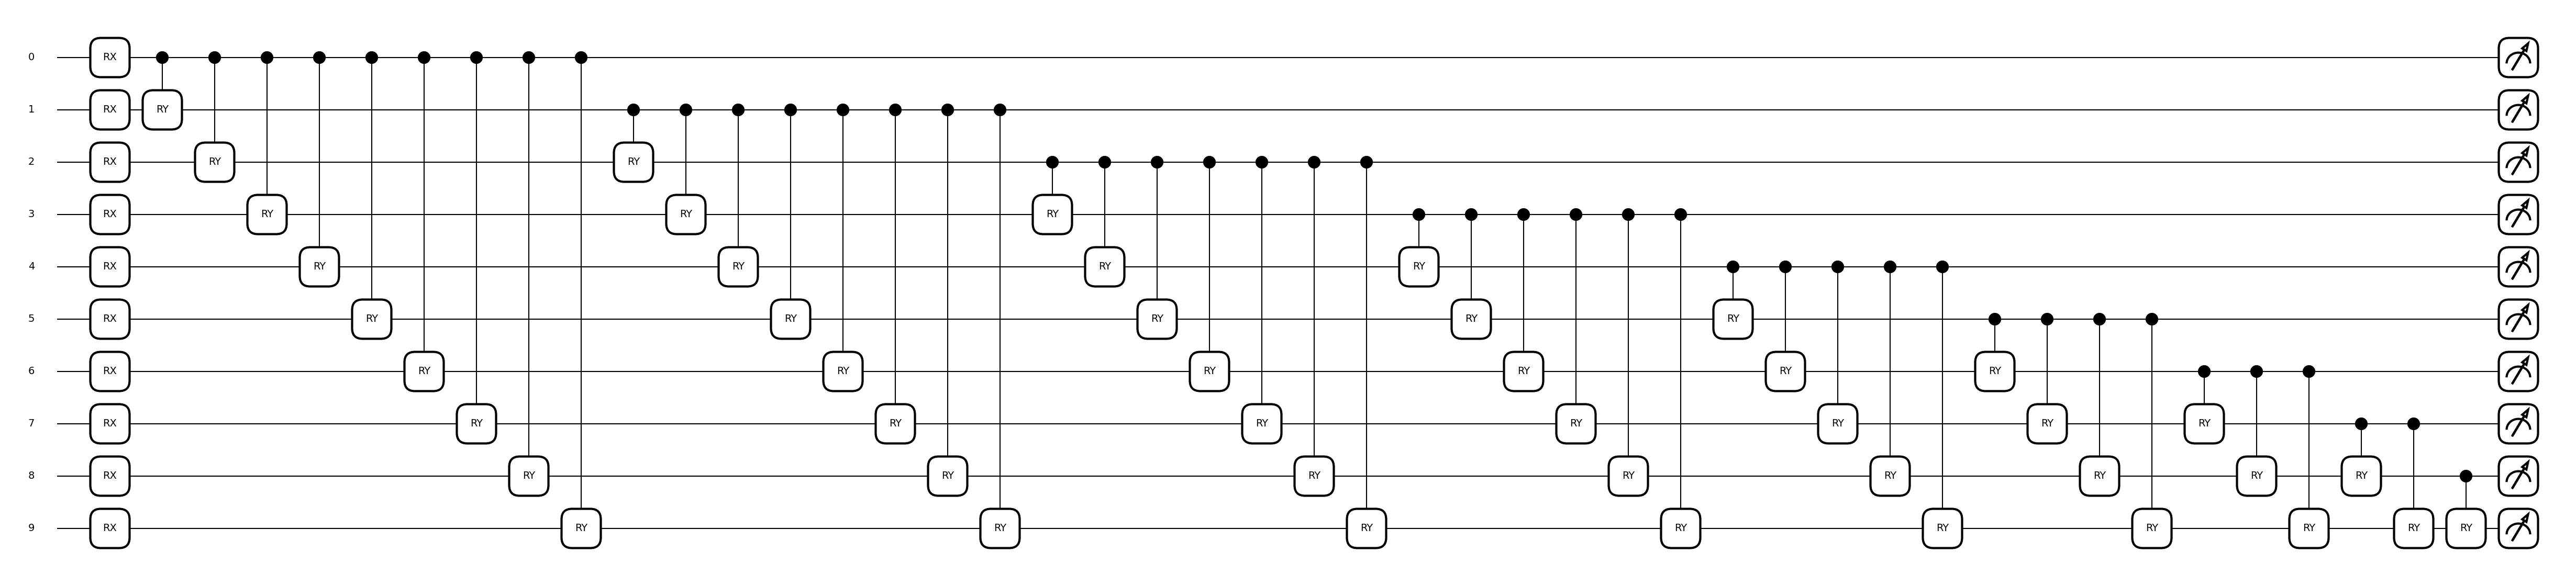

In [ ]:
import pennylane as qp
from itertools import combinations

dev = qp.device("default.qubit", wires=QUBITS)
pairs = list(combinations(range(QUBITS), 2)) 

@qp.qnode(dev)
def circuit(x):
    for i in range(QUBITS):
        qp.RX(0.0, wires=i)

    for (a, b) in pairs:
        qp.CRY(0.0, wires=[a, b])

    return qp.expval(triangle_observable())

fig, ax = qp.draw_mpl(circuit)(0.0)
fig.show()